# Participation Coefficient Analysis 

How much are nodes connected to other modules...

analysis from numberline/group_comparison_01.ipynb in DNumRisk

In [1]:
import nibabel as nib
import numpy as np
import os
import pandas as pd

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
ses = 1

subList = [f'{int(sub):02d}' for sub in range(1, 67)]
subArray = np.array(subList)


In [2]:
group_mapping = pd.read_csv(os.path.join(bids_folder, 'group_assignment.csv'))

from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
#mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

ci = glasser_CAatlas_mapping['ca_network'].values # community affiliation vector

In [ ]:
CMs = []
subArray = []
for sub in subList:
    try:
        cm = np.load(os.path.join(bids_folder, 'derivatives', 'correlation_matrices.parcel', f'sub-{sub}_glasserParcel-fsaverage_confspec-36Pscrub3BPfilter.npy'))  # generated with getCM_parcel.py
        CMs.append(cm)
        subArray.append(sub)
    except FileNotFoundError:
        print(f"File not found for subject {sub}")
subArray = np.array(subArray).astype(int)

In [11]:
from utils import participation_coef, threshold_matrix

df_PCs = []
df_meanNet_PCs = []
net_names = CAatlas_names['Network Name'].values

for cm in CMs:
    cm = threshold_matrix(cm, proportion=0.15)  # Threshold the matrix to keep only the top 15% of connections
    part_coefs = participation_coef(cm, ci)
    sub_meanNet_PCs = []
    for i_net in CAatlas_names.index.values:
        mask = (ci == i_net)
        sub_meanNet_PCs.append(part_coefs[mask].mean())
    df_meanNet_PCs.append(sub_meanNet_PCs)
    df_PCs.append(part_coefs) 

df_PCs = pd.DataFrame(df_PCs, index=subArray, columns=[f'parcel_{i}' for i in range(len(ci))])   
df_meanNet_PCs = pd.DataFrame(df_meanNet_PCs, index=subArray, columns=net_names)
df_meanNet_PCs.index.name = 'subject'

df_meanNet_PCs = df_meanNet_PCs.join(group_mapping.set_index('subject'), on='subject')

/home/ubuntu/git/parietal_patterns/common_connectivity_stuff/utils.py:42: RuntimeWarning: invalid value encountered in divide
  P = np.ones((n,)) - (Kc2 / np.square(Ko))  # divide


In [12]:
df_meanNet_PCs

,Visual1,Visual2,Somatomotor,Cingulo-Opercular,Dorsal-attention,Language,Frontoparietal,Auditory,Default,Posterior-Multimodal,Ventral-Multimodal,Orbito-Affective,group
subject,,,,,,,,,,,,,
1,0.608882,0.344207,0.416081,0.567536,0.732893,0.610293,0.571704,0.518904,0.362748,0.712026,0.473619,0.538678,0
2,0.649045,0.358831,0.611796,0.620597,0.708460,0.670018,0.627480,0.598318,0.410323,0.727473,0.749036,0.479957,1
3,0.702911,0.396209,0.527235,0.676688,0.689174,0.687147,0.641430,0.720662,0.499104,0.761818,0.552007,0.662629,0
4,0.632369,0.328838,0.419436,0.583499,0.637191,0.482057,0.538669,0.601026,0.288337,0.613508,0.240545,0.300148,1
5,0.493411,0.299095,0.436492,0.594214,0.707182,0.654709,0.583679,0.565574,0.378622,0.745453,0.576800,0.600655,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,0.497582,0.332029,0.411226,0.524942,0.666904,0.559603,0.476421,0.502224,0.328977,0.709568,0.620184,0.399581,0
63,0.564468,0.302875,0.487122,0.568772,0.722087,0.651471,0.584429,0.641344,0.382313,0.740610,0.614141,0.525660,0
64,0.621123,0.352670,0.553824,0.590203,0.686931,0.596742,0.610902,0.604177,0.425806,0.729393,0.631126,0.582564,0


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)

Text(0.5, 1.1, 'DNumRisk Study \n Participation Coefficient by Network - Group Comparisons')

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


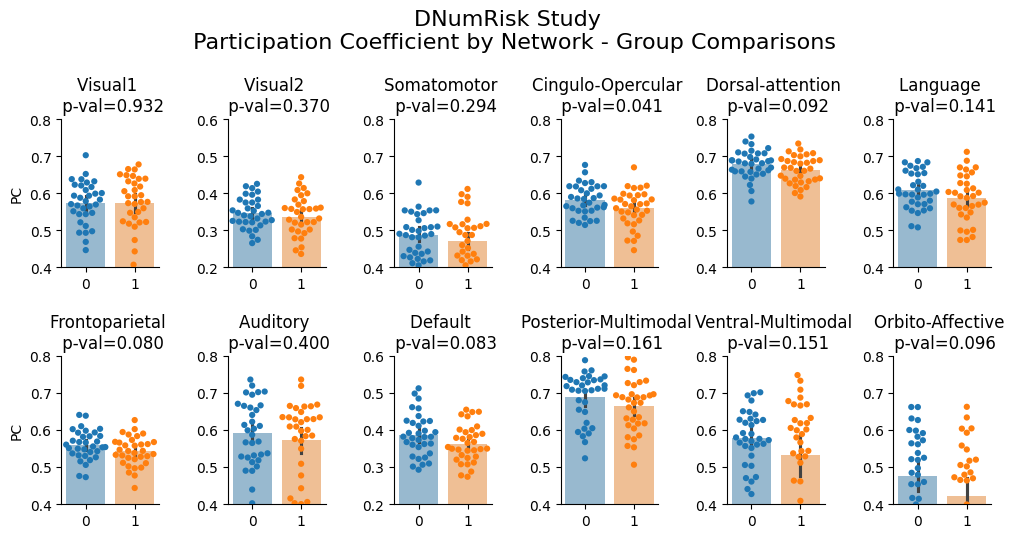

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

fig, axs = plt.subplots(2,6, figsize=(12,5))
axs = axs.flatten()

tmp = df_meanNet_PCs.set_index('group',append=True)

for i, net in enumerate(net_names):
        y_var = net
        sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False,ax=axs[i])
        sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=4.5,legend=False,ax=axs[i])
        stats = ttest_ind(tmp.xs(0,0,'group')[net], tmp.xs(1,0,'group')[net], axis=0, equal_var=False)
        axs[i].set(title=f'{y_var} \n p-val={stats.pvalue:.3f}', xlabel=None,ylim=(.4,.8))
        axs[i].set(ylabel='PC') if i == 0 or i == 6 else axs[i].set(ylabel=None)
        sns.despine()
axs[1].set(ylim=(.2,.6)) # visual2 is different
axs[8].set(ylim=(.2,.6)) # DMN is different

fig.subplots_adjust(hspace=0.6, wspace=0.7)
fig.suptitle('DNumRisk Study \n Participation Coefficient by Network - Group Comparisons', fontsize=16, y= 1.1)